## US-08 · Distribuzione delle Variabili Numeriche per Classe Churn

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

sys.path.append(os.path.abspath(".."))

df = pd.read_csv('../data/processed/data_clean.csv')
print(df.shape)

(7043, 37)


In [12]:
print(df.columns.tolist())

['age', 'avg_monthly_gb_download', 'avg_monthly_ld_charges', 'churn', 'cltv', 'contract', 'dependents', 'device_protection_plan', 'gender', 'internet_service', 'internet_type', 'married', 'monthly_charge', 'multiple_lines', 'num_dependents', 'num_referrals', 'offer', 'online_backup', 'online_security', 'paperless_billing', 'partner', 'payment_method', 'phone_service', 'population', 'premium_tech_support', 'referred_a_friend', 'senior_citizen', 'streaming_movies', 'streaming_music', 'streaming_tv', 'tenure_months', 'total_charges', 'total_extra_data_charges', 'total_ld_charges', 'total_refunds', 'total_revenue', 'unlimited_data']


In [13]:
numeric_vars = [
    'monthly_charge',
    'tenure_months',
    'total_charges',
    'age',
    'avg_monthly_gb_download',
    'avg_monthly_ld_charges',
    'total_revenue',
    'total_refunds'
]

✅ Grafico salvato in: /Users/antoniohopee/Desktop/projects/telco-churn-ml/outputs/figures/us08_distribuzioni_numeriche.png


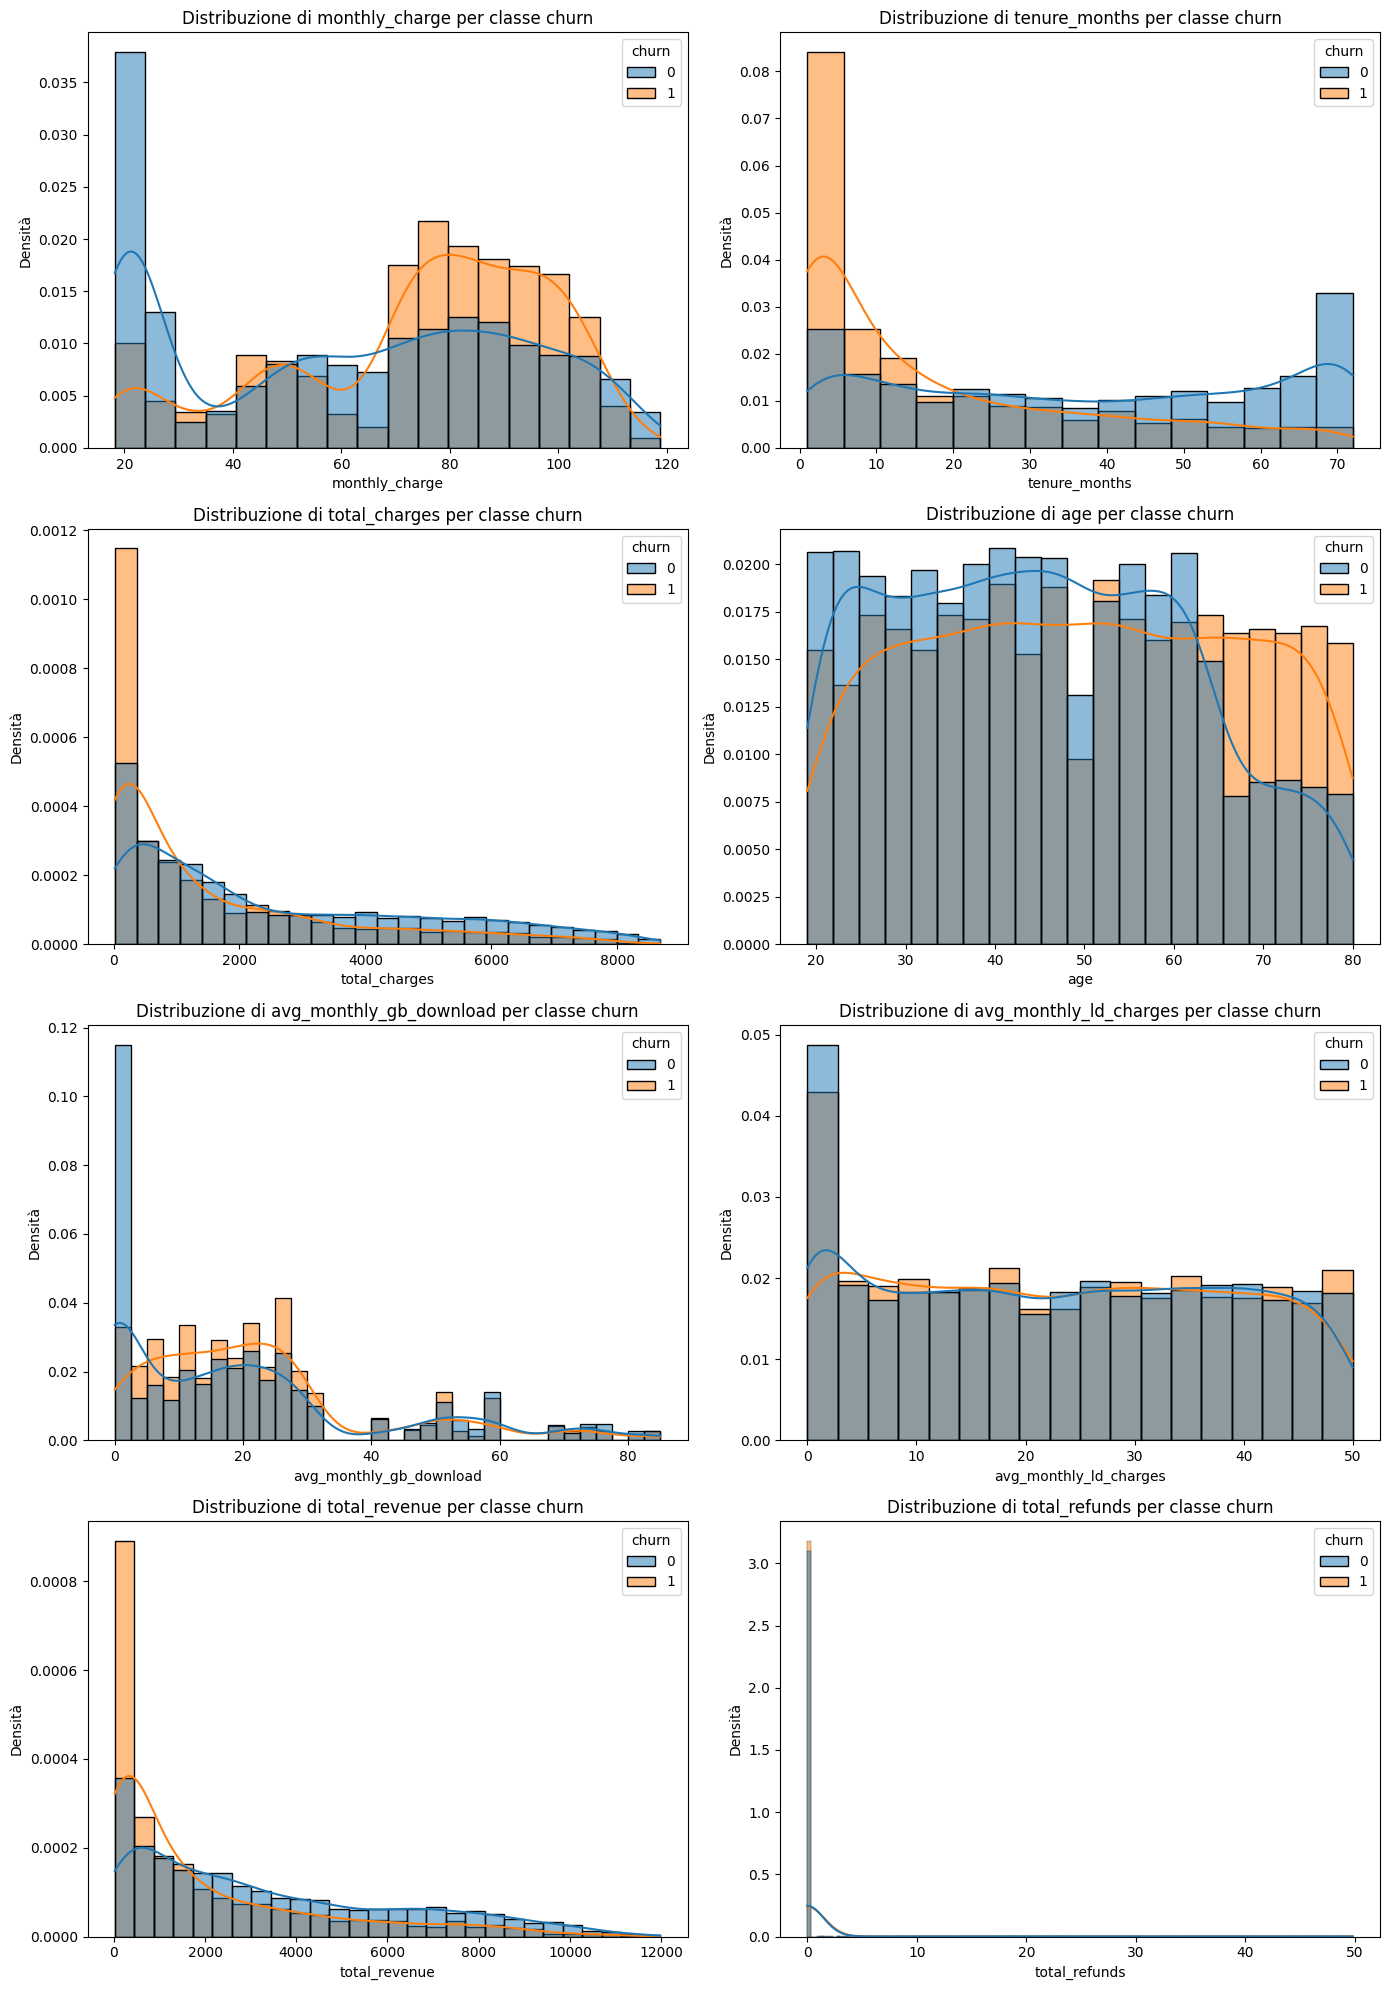

In [14]:
from src.visualization import plot_numeric_distributions

figures_path = os.path.abspath(os.path.join("..", "outputs", "figures", "us08_distribuzioni_numeriche.png"))

plot_numeric_distributions(
    df=df,
    variables=numeric_vars,
    target_col='churn',
    save_path=figures_path
)

### Osservazioni

- **monthly_charge**: separazione netta tra le due classi — i clienti churned 
  si concentrano nella fascia 70-120€, mentre i non churned sono prevalentemente 
  sotto i 40€. Ottimo predittore.

- **tenure_months**: separazione molto netta — i clienti churned si concentrano 
  nei primi mesi (0-10), mentre i non churned hanno tenure alta (60-70 mesi). 
  Chi è cliente da poco è fortemente a rischio abbandono.

- **total_charges**: i clienti churned hanno totale addebitato molto basso 
  (concentrati vicino a 0), coerente con la tenure bassa. Le distribuzioni 
  si separano chiaramente.

- **age**: le due distribuzioni si sovrappongono molto su tutto il range 20-80 anni. 
  Variabile poco discriminante da sola — l'età non sembra influenzare 
  significativamente il churn.

- **avg_monthly_gb_download**: i clienti churned tendono ad avere consumi dati 
  più alti (distribuzione spostata verso destra). Possibile correlazione 
  con piani più costosi.

- **avg_monthly_ld_charges**: le due distribuzioni si sovrappongono quasi 
  completamente — variabile poco discriminante per il churn.

- **total_revenue**: pattern simile a total_charges — i clienti churned 
  hanno revenue totale molto bassa, coerente con la tenure breve.

- **total_refunds**: quasi tutti i clienti (sia churned che non) hanno rimborsi 
  vicini a zero — la variabile non distingue le due classi ed è 
  probabilmente poco utile per il modello.

## US-09 · Analisi delle Variabili Categoriche rispetto al Churn

L'obiettivo è quantificare il tasso di churn per le principali variabili categoriche,
al fine di identificare i segmenti di clientela a maggior rischio di abbandono.
Le variabili analizzate sono: `contract`, `internet_type`, `payment_method`, `offer`.

In [15]:
# Variabili categoriche di interesse
categorical_vars = ['contract', 'internet_type', 'payment_method', 'offer']

# Tasso di churn per categoria (groupby + mean sul target binario)
for var in categorical_vars:
    churn_rate = df.groupby(var)['churn'].mean().mul(100).round(1).sort_values(ascending=False)
    print(f"\n--- {var.upper()} ---")
    print(churn_rate.to_string())


--- CONTRACT ---
contract
Month-to-Month    45.8
One Year          10.7
Two Year           2.5

--- INTERNET_TYPE ---
internet_type
Fiber Optic    40.7
Cable          25.7
DSL            18.6
No Internet     7.4

--- PAYMENT_METHOD ---
payment_method
Mailed Check       36.9
Bank Withdrawal    34.0
Credit Card        14.5

--- OFFER ---
offer
Offer E     52.9
No Offer    27.1
Offer D     26.7
Offer C     22.9
Offer B     12.3
Offer A      6.7


In [16]:
import importlib
import src.visualization
importlib.reload(src.visualization)

<module 'src.visualization' from '/Users/antoniohopee/Desktop/projects/telco-churn-ml/src/visualization.py'>

Grafico salvato in: /Users/antoniohopee/Desktop/projects/telco-churn-ml/outputs/figures/us09_churn_per_categoria.png


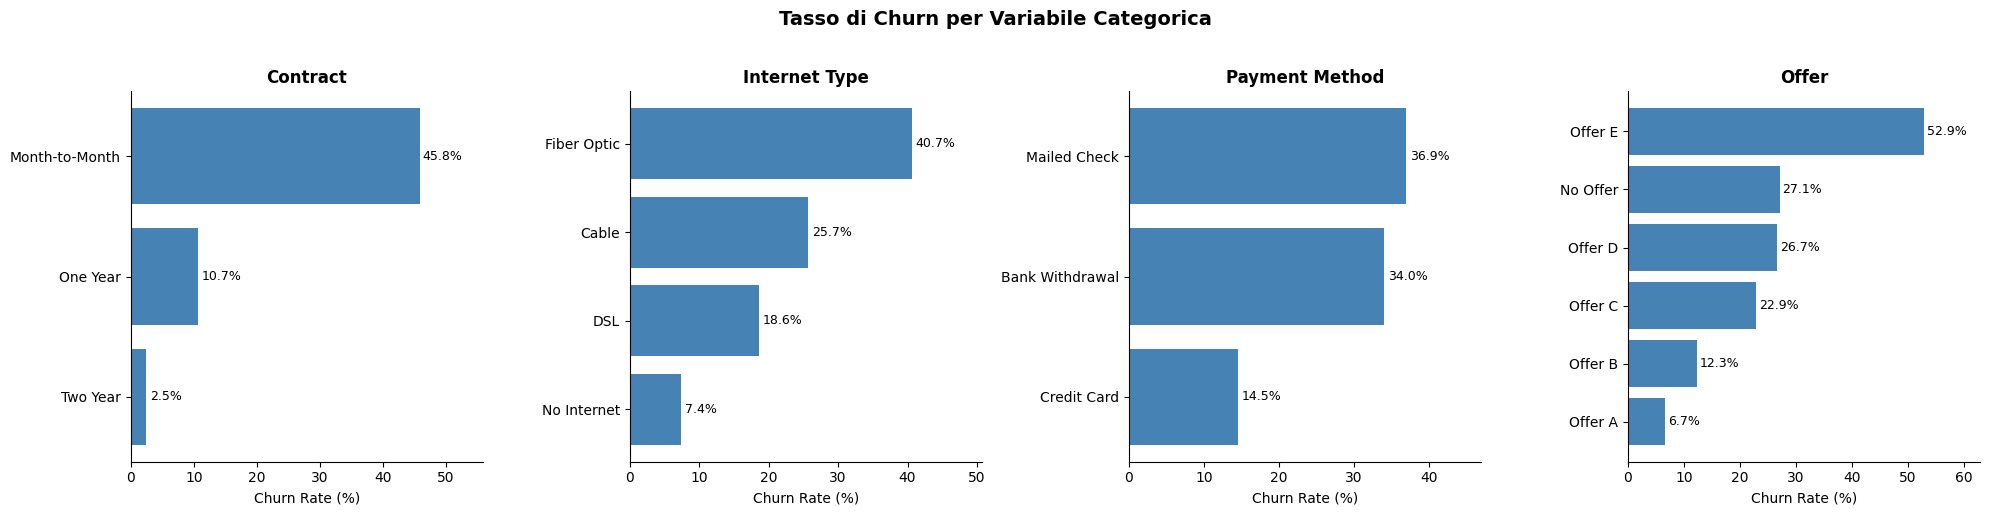

In [17]:
from src.visualization import plot_categorical_churn_rates

figures_path = os.path.abspath(os.path.join("..", "outputs", "figures", "us09_churn_per_categoria.png"))

plot_categorical_churn_rates(
    df=df,
    variables=categorical_vars,
    target_col='churn',
    save_path=figures_path
)

### Osservazioni

| Variabile | Categoria a maggior rischio | Churn Rate | Categoria a minor rischio | Churn Rate |
|---|---|---|---|---|
| Contract | Month-to-Month | 45.8% | Two Year | 2.5% |
| Internet Type | Fiber Optic | 40.7% | No Internet | 7.4% |
| Payment Method | Mailed Check | 36.9% | Credit Card | 14.5% |
| Offer | Offer E | 52.9% | Offer A | 6.7% |

**Contract**: la variabile più discriminante dell'analisi. I clienti con contratto 
mensile abbandonano a un tasso 18 volte superiore rispetto ai biennali (45.8% vs 2.5%). 
La fidelizzazione contrattuale è il principale fattore di retention identificato.

**Internet Type**: i clienti Fiber Optic mostrano il tasso di churn più alto (40.7%), 
nonostante — o forse a causa di — il servizio premium. Questo suggerisce aspettative 
più elevate e maggiore sensibilità al rapporto qualità/prezzo.

**Payment Method**: i clienti con pagamento automatico via carta di credito churned 
significativamente meno (14.5%) rispetto a chi paga con assegno cartaceo (36.9%). 
L'attrito del pagamento manuale potrebbe correlare con una minore fidelizzazione attiva.

**Offer**: Offer E presenta il tasso di churn più critico (52.9%), superiore persino 
ai clienti senza nessuna offerta (27.1%). Questo dato richiede un'analisi dedicata 
da parte del team commerciale: l'offerta potrebbe attrarre segmenti ad alto rischio 
o generare aspettative non mantenute. Offer A è invece la più efficace (6.7%).

**Implicazione strategica**: le leve più azionabili per la retention sono la 
conversione dei contratti mensili verso formule pluriennali e la revisione di Offer E.

# US-10 · Matrice di Correlazione #

## Con il seguente codice andiamo a selezionare le colonne numeriche escludendo le binarie e rimuoviamo il target dalla matrice

In [18]:
num_cols = df.select_dtypes(include='number').columns.tolist()

num_cols = [col for col in num_cols if col != 'churn']

corr_matrix = df[num_cols].corr()

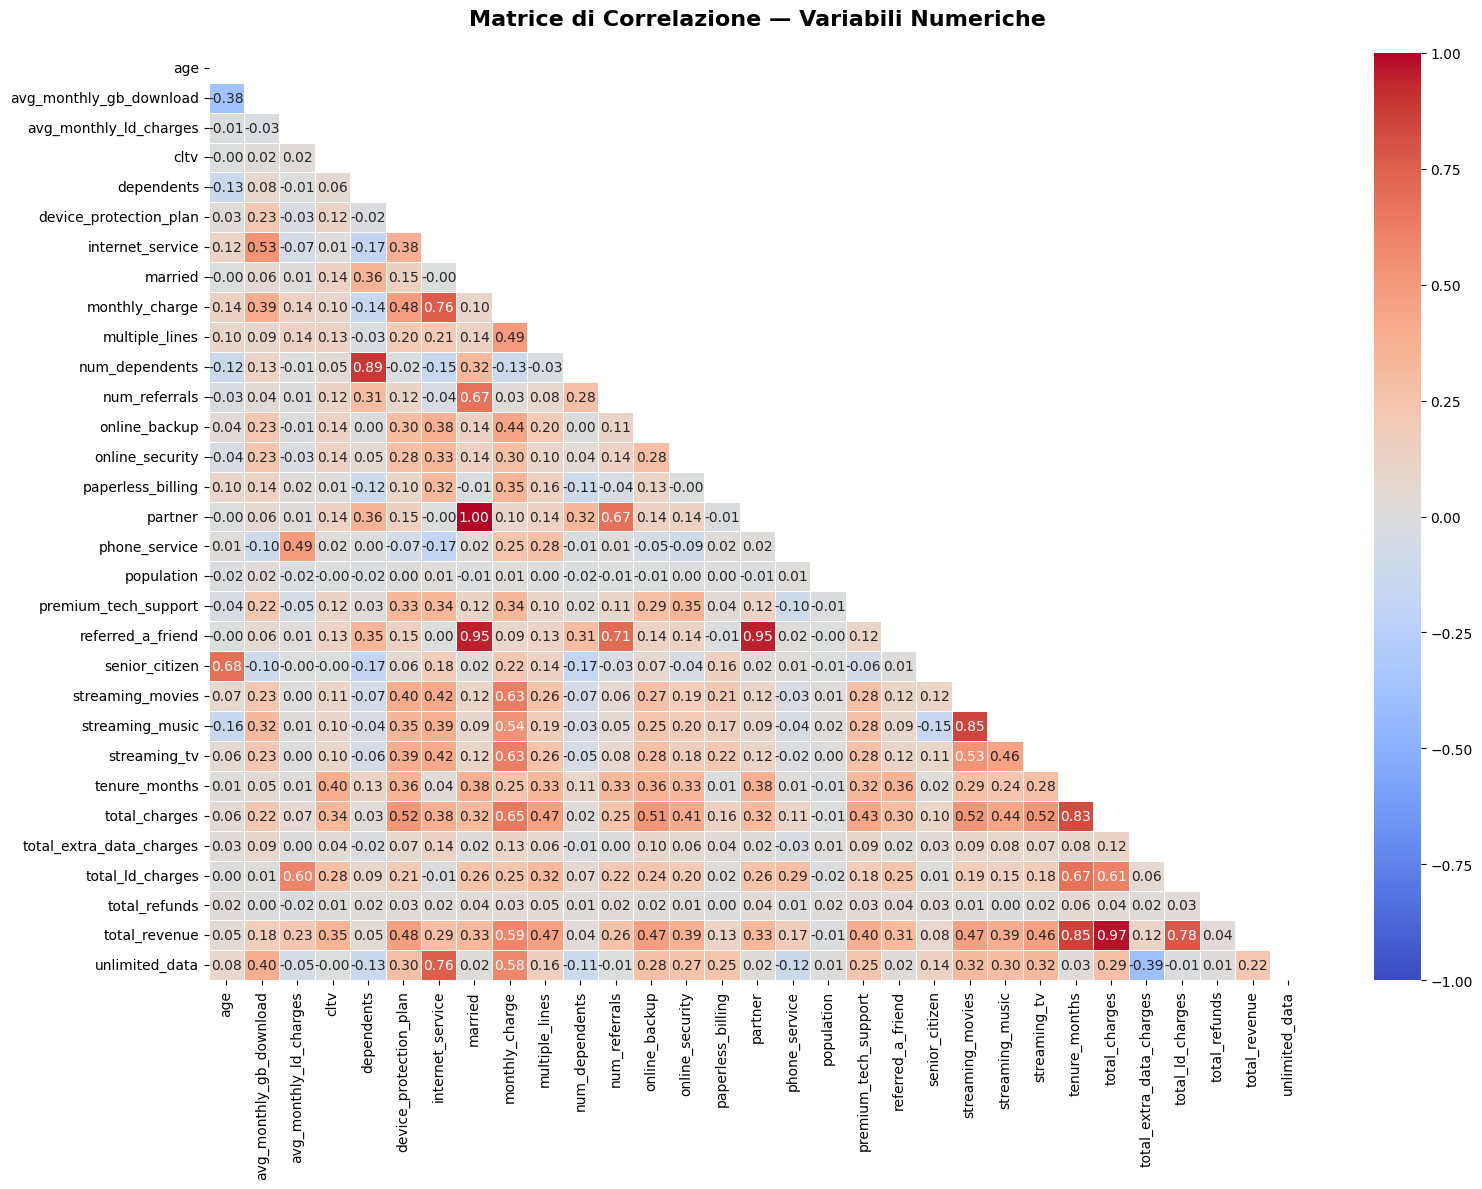

✅ Grafico salvato in: /Users/antoniohopee/Desktop/projects/telco-churn-ml/outputs/figures/us10_matrice_correlazione.png


In [19]:
import numpy as np

# La mask nasconde la metà superiore (simmetrica) per leggibilità
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(16, 12))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax
)

ax.set_title('Matrice di Correlazione — Variabili Numeriche', 
             fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()

figures_path = os.path.abspath(os.path.join("..", "outputs", "figures", "us10_matrice_correlazione.png"))
plt.savefig(figures_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Grafico salvato in: {figures_path}")

## Con il seguente codice andiamo a verificare quali coppie di variabili hanno una correlazione superiore a 0.8 (in valore assoluto), per identificare eventuali ridondanze o relazioni molto forti tra le variabili numeriche.


In [20]:

soglia = 0.8

coppie_alte = []

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        val = corr_matrix.iloc[i, j]
        if abs(val) > soglia:
            coppie_alte.append({
                'Variabile 1': corr_matrix.columns[i],
                'Variabile 2': corr_matrix.columns[j],
                'Correlazione': round(val, 3)
            })

df_coppie = pd.DataFrame(coppie_alte).sort_values('Correlazione', ascending=False)
print(f"Coppie con correlazione > {soglia}:")
display(df_coppie)

Coppie con correlazione > 0.8:


,Variabile 1,Variabile 2,Correlazione
1,partner,married,1.000
7,total_revenue,total_charges,0.972
3,referred_a_friend,partner,0.950
2,referred_a_friend,married,0.950
0,num_dependents,dependents,0.888
6,total_revenue,tenure_months,0.853
4,streaming_music,streaming_movies,0.849
5,total_charges,tenure_months,0.826


### Osservazioni matrice di correlazione

La matrice di correlazione serve a due scopi principali:

1. **Identificare variabili ridondanti** — Con la matrice di correlazione andiamo a verificare se due variabili sono estremamente correlate (es. 0.97) portano praticamente la stessa informazione al modello. Tenerle entrambe non aggiunge valore e può creare problemi.

2. **La matrice di correlazione** - Ci aiuta a capire le relazioni tra i dati nel dataset — Osservandola, si può già dedurre che:

| Variabile 1 | Variabile 2 | Correlazione | Osservazione |
|---|---|---|---|
| `partner` | `married` | 1.00 | Identiche |
| `total_revenue` | `total_charges` | 0.972 | Hanno una correlazione elevata e di conseguenza sono quasi identiche |
| `referred_a_friend` | `partner` | 0.950 | Alta correlazione con variabile identica a married |
| `referred_a_friend` | `married` | 0.950 | Stessa informazione espressa diversamente |
| `num_dependents` | `dependents` | 0.888 | Ridondanti di conseguenza forniscono la stessa informazione in forma diversa |
| `total_revenue` | `tenure_months` | 0.853 | Correlazione attesa: più a lungo un cliente resta, più revenue genera |
| `streaming_music` | `streaming_tv` | 0.849 | Hanno un'alta correlazione poiché chi dispone di un servizio streaming dispone anche dell'altro |
| `total_charges` | `tenure_months` | 0.826 | Correlazione attesa: totale addebitato cresce con la permanenza |

## US-11 · Analisi degli Outlier — Metodo Deviazione Standard

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys

sys.path.append(os.path.abspath(".."))

# Carica il dataset pulito
df = pd.read_csv(os.path.abspath(os.path.join("..", "data", "processed", "data_clean.csv")))

sns.set_theme(style="whitegrid")
print(f"Dataset caricato: {df.shape[0]} righe, {df.shape[1]} colonne")

Dataset caricato: 7043 righe, 37 colonne


In [22]:
# Selezioniamo solo le variabili numeriche continue
# Escludiamo le binarie (0/1) e il target
binarie = [
    'dependents', 'device_protection_plan', 'internet_service',
    'married', 'multiple_lines', 'online_backup', 'online_security',
    'paperless_billing', 'partner', 'phone_service', 'premium_tech_support',
    'referred_a_friend', 'senior_citizen', 'streaming_movies',
    'streaming_music', 'streaming_tv', 'unlimited_data', 'churn'
]

num_cols = [col for col in df.select_dtypes(include='number').columns
            if col not in binarie]

print(f"Variabili numeriche continue analizzate: {len(num_cols)}")
print(num_cols)

Variabili numeriche continue analizzate: 14
['age', 'avg_monthly_gb_download', 'avg_monthly_ld_charges', 'cltv', 'monthly_charge', 'num_dependents', 'num_referrals', 'population', 'tenure_months', 'total_charges', 'total_extra_data_charges', 'total_ld_charges', 'total_refunds', 'total_revenue']


In [28]:
from src.preprocessing import detect_outliers_std

df_outlier_std = detect_outliers_std(df, num_cols)
display(df_outlier_std)

,Variabile,Media,Dev. Std.,Limite inferiore,Limite superiore,N. Outlier,% Outlier
12,total_refunds,1.96,7.90,-21.75,25.67,266,3.78
10,total_extra_data_charges,6.86,25.10,-68.45,82.18,259,3.68
1,avg_monthly_gb_download,20.52,20.42,-40.74,81.77,91,1.29
11,total_ld_charges,749.10,846.66,-1790.88,3289.08,58,0.82
7,population,22139.60,21152.39,-41317.58,85596.78,57,0.81
5,num_dependents,0.47,0.96,-2.42,3.36,26,0.37
13,total_revenue,3034.38,2865.20,-5561.23,11629.99,5,0.07
6,num_referrals,1.95,3.00,-7.05,10.96,2,0.03
2,avg_monthly_ld_charges,22.96,15.45,-23.39,69.30,0,0.00
0,age,46.51,16.75,-3.74,96.76,0,0.00


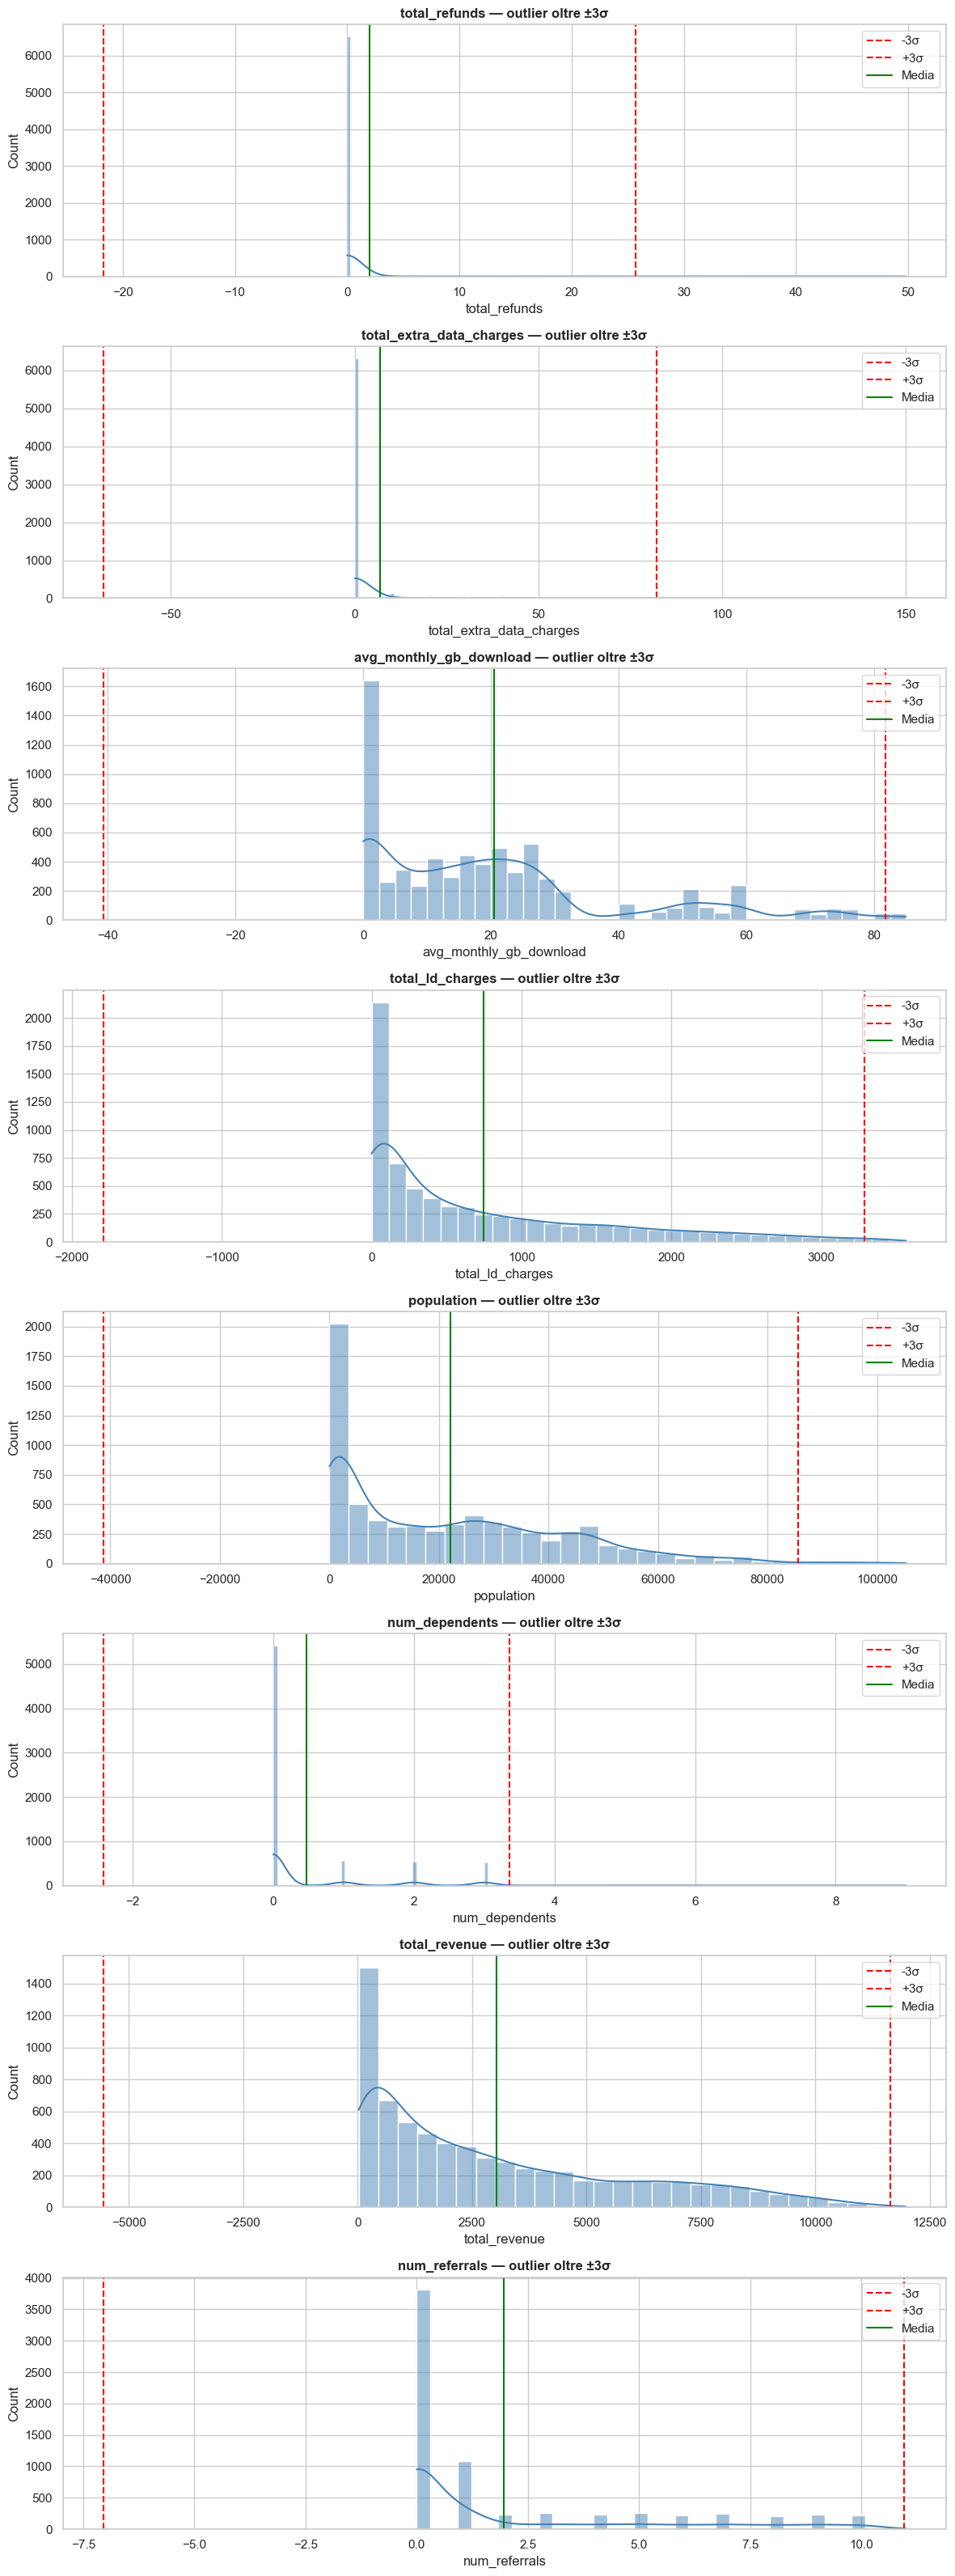

✅ Grafico salvato in: /Users/antoniohopee/Desktop/projects/telco-churn-ml/outputs/figures/us11_outlier_std.png


In [26]:
# Visualizziamo solo le variabili con almeno 1 outlier
cols_con_outlier = df_outlier_std[df_outlier_std['N. Outlier'] > 0]['Variabile'].tolist()

fig, axes = plt.subplots(len(cols_con_outlier), 1, figsize=(12, 4 * len(cols_con_outlier)))

for ax, col in zip(axes, cols_con_outlier):
    media = df[col].mean()
    std = df[col].std()
    
    sns.histplot(data=df, x=col, kde=True, ax=ax, color='steelblue')
    
    # Linee dei limiti ±3σ
    ax.axvline(media - 3 * std, color='red', linestyle='--', label='-3σ')
    ax.axvline(media + 3 * std, color='red', linestyle='--', label='+3σ')
    ax.axvline(media, color='green', linestyle='-', label='Media')
    
    ax.set_title(f'{col} — outlier oltre ±3σ', fontweight='bold')
    ax.legend()

plt.tight_layout()

figures_path = os.path.abspath(os.path.join("..", "outputs", "figures", "us11_outlier_std.png"))
plt.savefig(figures_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Grafico salvato in: {figures_path}")

### Osservazioni US-11 — Outlier con Deviazione Standard

**Variabili con outlier rilevati:**

| Variabile | N. Outlier | % | Valutazione |
|---|---|---|---|
| `total_refunds` | 266 | 3.78% | Plausibili — la maggior parte dei clienti ha rimborsi vicini a zero, pochi hanno rimborsi elevati. Distribuzione asimmetrica attesa. |
| `total_extra_data_charges` | 259 | 3.68% | Plausibili — la maggior parte paga 0€ di extra dati, pochi heavy user hanno costi elevati. |
| `avg_monthly_gb_download` | 91 | 1.29% | Plausibili — clienti con consumi dati molto alti (>81 GB/mese), probabilmente con piano illimitato. |
| `total_ld_charges` | 58 | 0.82% | Plausibili — clienti con molte chiamate internazionali. |
| `population` | 57 | 0.81% | Plausibili — alcune città californiane hanno popolazioni molto alte. |
| `num_dependents` | 26 | 0.37% | Plausibili — famiglie numerose, raro ma possibile. |
| `total_revenue` | 5 | 0.07% | Plausibili — clienti con tenure molto alta e canone elevato. |
| `num_referrals` | 2 | 0.03% | Plausibili — clienti molto fidelizzati che raccomandano spesso il servizio. |

**Variabili senza outlier:**
`age`, `monthly_charge`, `tenure_months`, `total_charges`, `cltv` — 
nessun valore oltre ±3σ. I range sono coerenti con il contesto reale.

**⚠️ Limite del metodo:**
Il metodo ±3σ produce limiti inferiori negativi per variabili come 
`total_refunds`, `total_extra_data_charges` e `total_revenue`. 
Valori negativi sono impossibili per queste variabili — è un artefatto 
matematico del metodo, che non tiene conto dei vincoli reali del dominio.
Questo limite sarà confrontato con il metodo IQR nella US-12, 
che gestisce meglio le distribuzioni asimmetriche.

**Conclusione generale:**
Nessun outlier è stato identificato come errore di inserimento dati. 
Tutti i valori anomali hanno una spiegazione plausibile nel contesto 
di una compagnia telefonica. Non verranno rimossi in questa fase —
la decisione finale verrà presa dopo il confronto con gli altri metodi.